# Preview: NEURON single case (`HH + fixed ion`)

这个 notebook 只用于临时预览当前 `NEURON` 单 case runner 的输入结构和输出结果。

当前只展示：

- 一个最小公共 case schema
- 一次自动 discovery 的结果
- `neuron_single_case.run_case(case)` 的返回结构
- `v` / `ix` / `gates` 的图


In [1]:
import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()

def find_template_root() -> Path:
    for candidate in (ROOT, *ROOT.parents):
        if (candidate / "case_schema.py").exists() and (candidate / "pair_manifest.py").exists():
            return candidate
        nested = candidate / "examples" / "neuron_compare" / "SC_channel" / "templates" / "hh_fixed_ion"
        if (nested / "case_schema.py").exists() and (nested / "pair_manifest.py").exists():
            return nested
    raise RuntimeError("Cannot locate SC_channel hh_fixed_ion templates directory.")

TEMPLATE_ROOT = find_template_root()

def load_local_module(name: str):
    path = TEMPLATE_ROOT / f"{name}.py"
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    assert spec is not None and spec.loader is not None
    spec.loader.exec_module(module)
    return module

pair_manifest = load_local_module("pair_manifest")
discovery = load_local_module("discovery")
case_schema = load_local_module("case_schema")
neuron_single_case = load_local_module("neuron_single_case")


In [2]:
payload = {
    "template_family": "single_compartment_channel",
    "template_variant": "hh_fixed_ion",
    "case_id": "kv_preview",
    "pair_id": "kv_test",
    "mod_dir": "/home/swl/braincell/examples/convert_mod/mod_validate/mods",
    "morphology": {
        "length_um": 10.0,
        "diam_um": 100.0 / 3.141592653589793,
        "cm_uF_cm2": 1.0,
    },
    "simulation": {
        "dt_ms": 0.025,
        "duration_ms": 2.0,
        "v_init_mV": -65.0,
        "temperature_celsius": 25.0,
    },
    "stimulus": {
        "kind": "dc",
        "delay_ms": 0.5,
        "dur_ms": 1.0,
        "amp_nA": 0.01,
    },
    "ion": {
        "mode": "fixed",
        "fixed_E_mV": -80.0,
    },
    "channel_overrides": {
        "g_max_S_cm2": 0.0,
        "v12_mV": 25.0,
        "q": 9.0,
    },
}

case = case_schema.SingleCompartmentChannelHHFixedIonCase.from_dict(payload)
case


SingleCompartmentChannelHHFixedIonCase(template_family='single_compartment_channel', template_variant='hh_fixed_ion', case_id='kv_preview', pair_id='kv_test', mod_dir='/home/swl/braincell/examples/convert_mod/mod_validate/mods', morphology=MorphologySpec(length_um=10.0, radius_um=15.915494309189533, cm_uF_cm2=1.0), simulation=SimulationSpec(dt_ms=0.025, duration_ms=2.0, v_init_mV=-65.0, temperature_celsius=25.0), stimulus=DCStimulusSpec(kind='dc', delay_ms=0.5, dur_ms=1.0, amp_nA=0.01), ion=FixedIonSpec(ion_type=None, mode='fixed', fixed_E_mV=-80.0, fixed_Ci_mM=None, fixed_Co_mM=None, valence=None), channel_overrides={'g_max_S_cm2': 0.0, 'v12_mV': 25.0, 'q': 9.0}, leak=LeakSpec(enabled=False, g_S_cm2=0.0, e_mV=-65.0), compare=CompareSpec(gate_names=None, gate_name_map=None))

In [3]:
pair = pair_manifest.get_pair_entry(case.pair_id)
neuron_meta = discovery.discover_neuron_channel_metadata(case.mod_dir, pair.neuron_mechanism_name)

print("pair:", pair)
print("discovered neuron metadata:", neuron_meta)

result = neuron_single_case.run_case(case)

print("result keys:", result.keys())
print("time shape:", result["time_ms"].shape)
print("voltage shape:", result["voltage_mV"].shape)
print("current keys:", result["current"].keys())
print("gate keys:", sorted(result["gates"].keys()))


pair: PairEntry(pair_id='kv_test', description='Minimal Kv HH-style pair used for the first template preview.', neuron_mechanism_name='Kv', braincell_channel_name='IK_Kv_test', ion_type_override=None, gate_name_map=None, notes=('This pair is the first smoke-test target for HH + fixed-ion.',))
discovered neuron metadata: NeuronChannelMetadata(mechanism_name='Kv', gate_names=('n',), ion_type='k', current_field='i', current_owner='mechanism', parameter_names=('gbar', 'q', 'v12'))
Mechanisms already loaded from path: /home/swl/braincell/examples/convert_mod/mod_validate/mods.  Aborting.
Mechanisms already loaded from path: /home/swl/braincell/examples/convert_mod/mod_validate/mods.  Aborting.
result keys: dict_keys(['time_ms', 'voltage_mV', 'current', 'gates'])
time shape: (80,)
voltage shape: (80,)
current keys: dict_keys(['ix'])
gate keys: ['n']


--No graphics will be displayed.


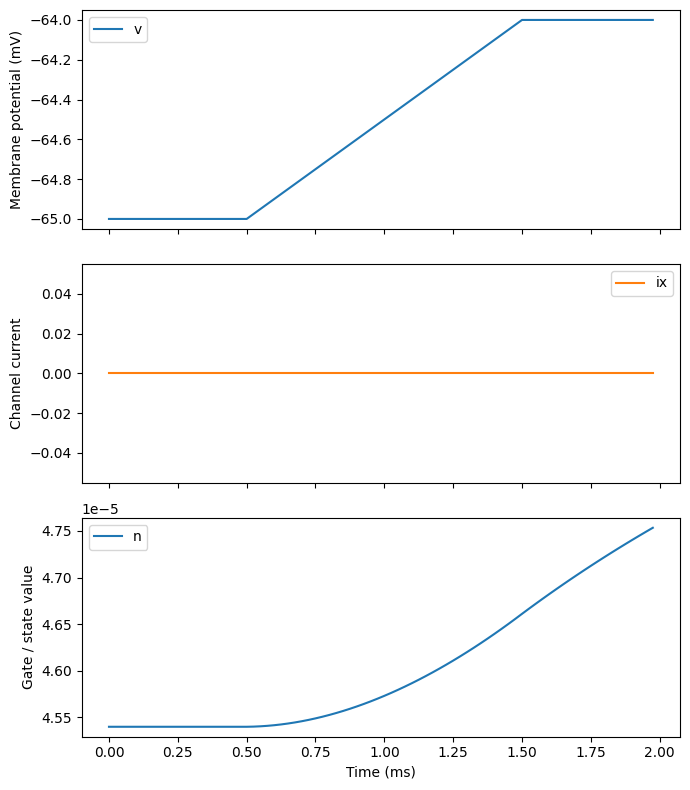

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)

axes[0].plot(result["time_ms"], result["voltage_mV"], label="v")
axes[0].set_ylabel("Membrane potential (mV)")
axes[0].legend()

axes[1].plot(result["time_ms"], result["current"]["ix"], label="ix", color="tab:orange")
axes[1].set_ylabel("Channel current")
axes[1].legend()

for gate_name in sorted(result["gates"]):
    axes[2].plot(result["time_ms"], result["gates"][gate_name], label=gate_name)
axes[2].set_xlabel("Time (ms)")
axes[2].set_ylabel("Gate / state value")
axes[2].legend()

plt.tight_layout()
plt.show()
